# 📈 Shortest-Path Percolation — Dynamic Plots

This notebook loads Shortest-Path Percolation (SPP) simulation output, averages the results over independent realizations, and plots the relative size of the giant connected component, $N_G/N$, as a function of the fraction of removed elements $p$, for different values of the shortest-path constraint $C$.

English version of `plot-spp-dynamic.ipynb`.

## Required Libraries

In [1]:
# Core libraries
import os
import datetime

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

## Simulation Data Layout

Each simulation run is stored as a single file under:

```
data_notebook/N{N}/{attack_mode}/C{C}/
```

where `N` is the network size, `attack_mode` describes how the two endpoints of each removed edge are chosen (e.g. `hub1-random2` = one endpoint chosen by degree/hub centrality, the other at random), and `C` is the shortest-path length constraint used by the percolation rule. Every file inside one of these folders is an **independent realization** of the same process, and the notebook averages over all of them.

Columns in each file:

| Column | Meaning |
|---|---|
| `p` | fraction of removed edges/nodes |
| `m1` | relative size of the giant component, $N_G/N$ |
| `m2`, `m3`, `m4` | relative sizes of the 2nd–4th largest components (CSV files only) |
| `s` | susceptibility ($\chi$) |
| `node1`, `node2` | endpoints of the removed edge |
| `t` | update / time step |

`.npz` files store only `p`, `m1`, `s`, `node1`, `node2`, `t`; `.csv` / `.csv.gz` files also include `m2`, `m3`, `m4`.

## Data Loading, Processing, and Plotting

### Text Style Helper

In [2]:
def set_cm_text_style(prefer_tex=True):
    '''
    Set matplotlib text style to Computer Modern (LaTeX) or fallback serif.

    Parameters
    ----------
    prefer_tex : bool, optional
        If True, enable LaTeX rendering; otherwise use built-in serif fonts.
    '''
    if prefer_tex:
        plt.rcParams.update({
            "text.usetex": True,
            "font.family": "serif",
            "font.serif": ["Computer Modern Roman"],
            "axes.unicode_minus": False,
            "pgf.preamble": r"\usepackage{amsmath}\usepackage{bm}",
        })
    else:
        plt.rcParams.update({
            "text.usetex": False,
            "font.family": "serif",
            "font.serif": ["DejaVu Serif"],
            "mathtext.fontset": "cm",
            "mathtext.rm": "serif",
            "mathtext.it": "serif:italic",
            "mathtext.bf": "serif:bold",
            "axes.unicode_minus": False,
        })

### Locating Simulation Files

Given `(N, C, attack_mode)`, this returns every realization file — plain CSV, gzip-compressed CSV, or NumPy `.npz` — found in the corresponding folder.

In [3]:
def list_simulation_files(N, C, attack_mode="hub1-hub1"):
    '''
    List simulation files for (N, C, attack_mode) under data_notebook/.
    Accepts plain CSV (.csv), compressed CSV (.csv.gz/.gz) and NumPy (.npz).
    '''
    data_dir = f'./data_notebook/N{N}/{attack_mode}/C{C}/'

    if not os.path.exists(data_dir):
        print(f"[WARNING] Directory not found: {data_dir}")
        return []

    valid_exts = (".csv", ".csv.gz", ".gz", ".npz")
    files = [
        os.path.join(data_dir, f)
        for f in os.listdir(data_dir)
        if f.endswith(valid_exts)
    ]
    files.sort()
    return files

### Reading a Single Realization

Parses one file into a DataFrame with a consistent column layout, regardless of whether it is `.npz` or CSV.

In [4]:
def read_simulation_file(file_name, drop_node=True):
    '''
    Read a single simulation file (.npz or CSV) into a DataFrame with
    columns p, m1, [m2, m3, m4,] s, node1, node2, t.
    '''
    if file_name.endswith(".npz"):
        data = np.load(file_name)
        df = pd.DataFrame({
            "p": data["removed"],
            "m1": data["largest"],
            "s": data["chi"],
            "node1": data["edges_a"],
            "node2": data["edges_b"],
            "t": data["update_time"],
        })
        if drop_node:
            return df.drop(columns=["node1", "node2"], errors="ignore")
        return df

    col_names = ["p", "m1", "m2", "m3", "m4", "s", "node1", "node2", "t"]
    df = pd.read_csv(
        file_name,
        sep=r"\s+",
        header=None,
        names=col_names,
        engine="c",
        dtype="float64",
        compression="infer",
    )
    if drop_node:
        return df.drop(columns=["node1", "node2"], errors="ignore")
    return df

### Averaging Across Realizations

For a given `(N, C, attack_mode)` there are usually many realization files — independent runs of the same stochastic percolation process. `compute_average_curves` combines them into a single **mean curve with an uncertainty band**, without ever holding every realization in memory at once:

1. **Stream, don't concatenate.** Each file is read and immediately reduced, one at a time. For every value of `p` present in that file, the code accumulates three running totals, grouped by `p`: the **sum** of each quantity (`m1`, `m2`, ..., `s`, `t`), the **sum of squares** of each quantity, and the **count** of samples. These running totals are added across files with pandas' `add(..., fill_value=0.0)`, so a `p` value that only appears in some files still merges correctly.
2. **Mean.** Once every file has been folded in, the sample mean at each `p` is simply `sum / count`.
3. **Standard deviation.** The (Bessel-corrected) sample variance is obtained from the running totals via the computational formula
   $$\mathrm{Var}(x) = \frac{1}{n-1}\left(\sum_i x_i^2 - \frac{(\sum_i x_i)^2}{n}\right),$$
   which only needs $\sum x_i$, $\sum x_i^2$, and $n$ — exactly the quantities accumulated in the streaming pass. The standard deviation is then $\sqrt{\mathrm{Var}(x)}$, clipped at 0 to guard against tiny negative values caused by floating-point rounding.
4. **Merge.** The mean and standard-deviation tables are joined on `p` into a single DataFrame, with columns such as `m1` (mean) and `m1_std` (standard deviation).

In the plots further below, the solid line is this mean curve and the shaded band is mean ± 1 standard deviation. It shows how much the giant-component size fluctuates from realization to realization — those fluctuations are typically largest near the percolation threshold.

In [5]:
def compute_average_curves(N, C, attack_mode="random", drop_node=True):
    '''
    Compute mean and std curves for given (N, C, attack_mode), grouped by p.
    Streams file-by-file (sum / sum-of-squares / count) instead of
    concatenating everything in memory, reading .npz and CSV files
    from data_notebook/.
    '''
    files = list_simulation_files(N, C, attack_mode=attack_mode)
    if not files:
        return pd.DataFrame()

    sum_df = None
    sumsq_df = None
    count_df = None

    for file_name in files:
        try:
            df = read_simulation_file(file_name, drop_node=drop_node)
            value_cols = [col for col in ["m1", "m2", "m3", "m4", "s", "t", "node1", "node2"] if col in df.columns]

            grp_sum = df.groupby("p", as_index=True)[value_cols].sum()
            grp_sumsq = (df[value_cols] ** 2).groupby(df["p"]).sum()
            grp_count = df.groupby("p", as_index=True).size().to_frame("count")

            if sum_df is None:
                sum_df, sumsq_df, count_df = grp_sum, grp_sumsq, grp_count
            else:
                sum_df = sum_df.add(grp_sum, fill_value=0.0)
                sumsq_df = sumsq_df.add(grp_sumsq, fill_value=0.0)
                count_df = count_df.add(grp_count, fill_value=0.0)
        except Exception as e:
            print(f"[ERROR] Failed to read {os.path.basename(file_name)}: {e}")

    if sum_df is None or count_df is None:
        return pd.DataFrame()

    n = count_df["count"]
    mean_df = sum_df.div(n, axis=0).reset_index()

    var_df = (sumsq_df - (sum_df ** 2).div(n, axis=0)).div((n - 1).clip(lower=1), axis=0)
    var_df = var_df.clip(lower=0.0)
    std_df = (var_df ** 0.5).reset_index()
    std_df = std_df.rename(columns={c: f"{c}_std" for c in sum_df.columns})

    return pd.merge(mean_df, std_df, on="p", how="inner")

### Plotting the Giant Component Curves

`plot_m1_single_N_all_C_means` calls `compute_average_curves` for `C ∈ {1, 2, 3, N}` at a fixed `N` and `attack_mode`, plots the resulting mean $m_1 = N_G/N$ curves (each with its ± std band) on one figure, and saves it as a PNG.

In [6]:
def plot_m1_single_N_all_C_means(N, attack_mode="random1-random2",
                                 prefer_tex=True, fill_std=True,
                                 save_with_timestamp=True):
    '''
    Plot m1 mean curves for all C ∈ {1,2,3,N} in one figure.
    '''
    set_cm_text_style(prefer_tex=prefer_tex)

    fig, ax = plt.subplots(figsize=(8.5, 6.2))
    ax.set_axisbelow(True)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

    C_values = [1, 2, 3, N]
    labels = {1: r"$C=1$", 2: r"$C=2$", 3: r"$C=3$", N: r"$C=N$"}
    markers = ["o", "s", "D", "^"]

    any_plotted = False
    for idx, C in enumerate(C_values):
        df = compute_average_curves(N, C, attack_mode=attack_mode)
        if df.empty or "p" not in df or "m1" not in df:
            print(f"[WARNING] No data for N={N}, C={C}, mode={attack_mode}.")
            continue

        ax.plot(df["p"], df["m1"],
                marker=markers[idx % len(markers)], linewidth=1.5, markersize=2.0,
                label=labels[C])

        if fill_std and "m1_std" in df.columns and not df["m1_std"].isna().all():
            m, s = df["m1"].to_numpy(), df["m1_std"].fillna(0).to_numpy()
            ax.fill_between(df["p"], m - s, m + s, alpha=0.18, linewidth=0)

        any_plotted = True

    if not any_plotted:
        print("[ERROR] No curves plotted (missing data).")
        return

    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.set_xlabel(r"$p$", fontsize=18)
    ax.set_ylabel(r"$N_{G}/N$", fontsize=18)
    ax.tick_params(labelsize=14, direction='in')
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: '' if v == 0 else f'{v:g}'))

    ax.legend(fontsize=13, frameon=True, fancybox=True, edgecolor='black', loc='best')
    ax.set_title(rf"$N={N}$ — {attack_mode}", fontsize=14)
    ax.grid(False)

    fig.tight_layout()

    ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    out = f"attack_{attack_mode}_N{N}_means_{ts}.png" if save_with_timestamp \
          else f"attack_{attack_mode}_N{N}_means.png"

    fig.savefig(out, dpi=300, bbox_inches='tight', transparent=True)
    print(f"[OK] Figure saved at: {out}")
    plt.show()

## Example Plots

Each example below averages every realization found for the given `(N, C, attack_mode)` and plots $N_G/N$ vs. $p$ for all four values of $C$.

### Plot for $N=10^{4}$, mode $hub–hub$

[OK] Figure saved at: attack_hub1-hub2_N10000_means.png


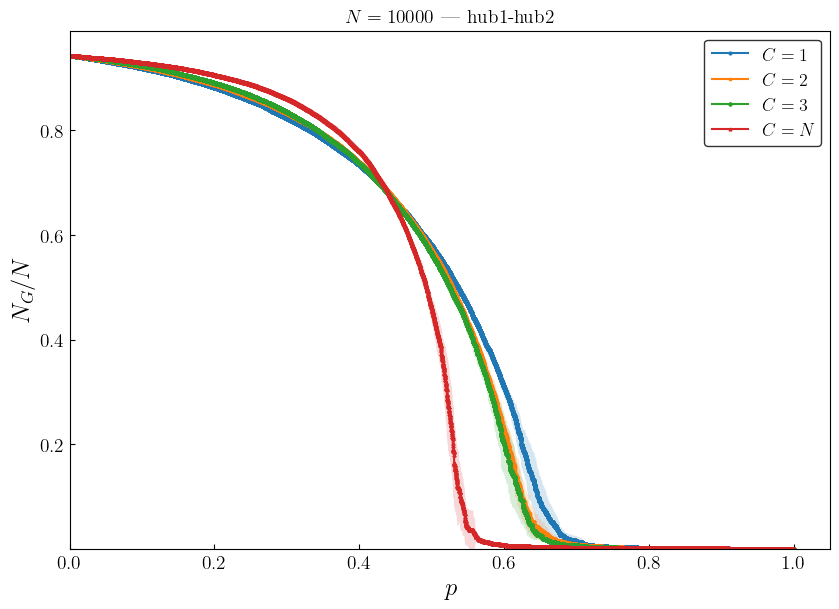

In [7]:
plot_m1_single_N_all_C_means(
    N=10000,
    attack_mode="hub1-hub2",
    prefer_tex=True,
    fill_std=True,
    save_with_timestamp=False)

### Plot for $N=10^{4}$, mode $random–random$

[OK] Figure saved at: attack_random1-random2_N10000_means.png


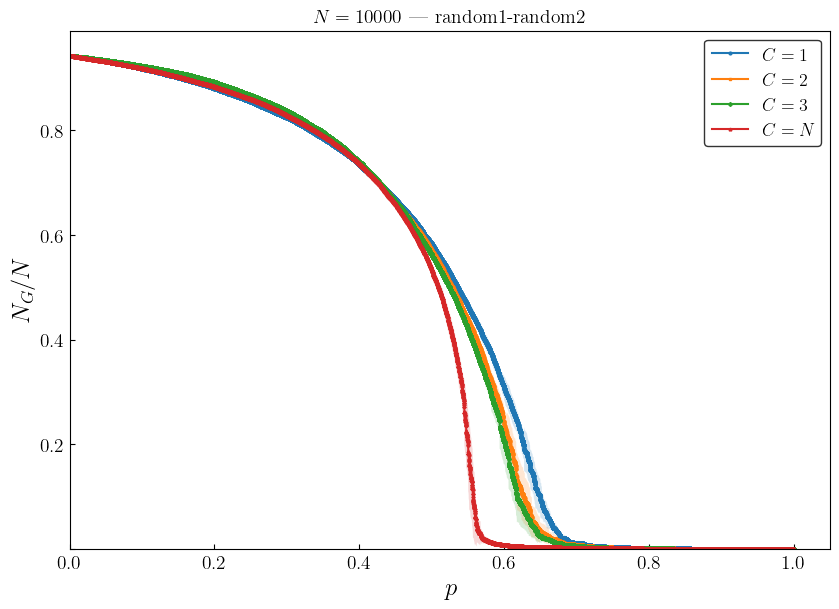

In [8]:
plot_m1_single_N_all_C_means(
    N=10000,
    attack_mode="random1-random2",
    prefer_tex=True,
    fill_std=True,
    save_with_timestamp=False)

### Plot for $N=500$, mode $closeness–random$

[OK] Figure saved at: attack_closeness1-random2_N500_means.png


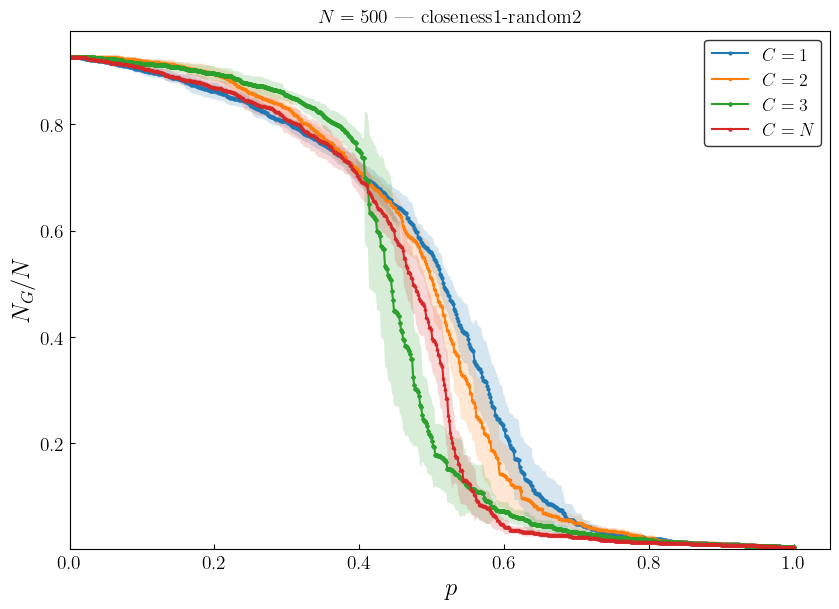

In [9]:
plot_m1_single_N_all_C_means(
    N=500,
    attack_mode="closeness1-random2",
    prefer_tex=True,
    fill_std=True,
    save_with_timestamp=False)

### Plot for $N=500$, mode $hub–hub$

[OK] Figure saved at: attack_hub1-hub2_N500_means.png


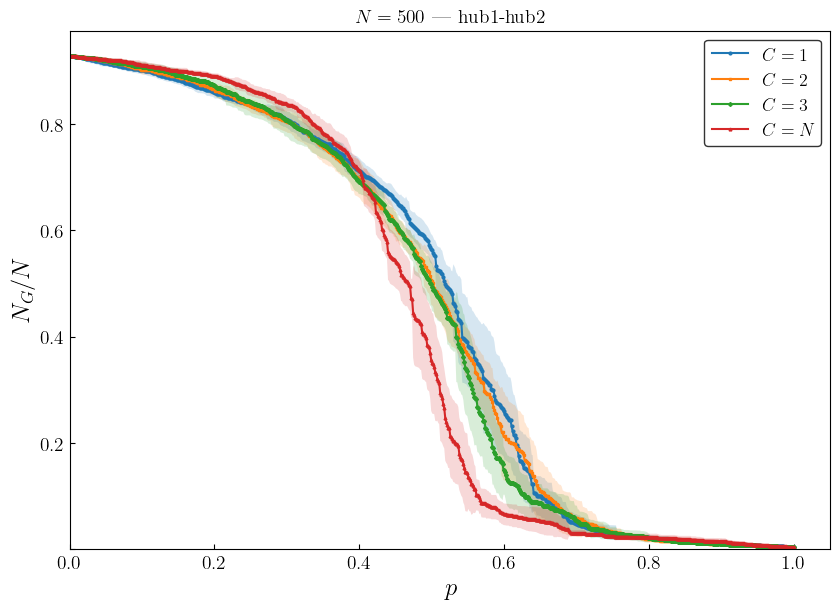

In [10]:
plot_m1_single_N_all_C_means(
    N=500,
    attack_mode="hub1-hub2",
    prefer_tex=True,
    fill_std=True,
    save_with_timestamp=False)